In [44]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["VTI", "VXUS", "SGOV"]
data = yf.download(tickers, start="2015-01-01")
df = pd.DataFrame(data)
monthly = df.resample("ME").last()
monthly = monthly.tail(12)
monthly = monthly['Close']
monthly
returns_6m = monthly.pct_change(6)
signals = []

for i in range(6, len(monthly)):
    row = returns_6m.iloc[i]

    if row["VTI"] < 0 and row["VXUS"] < 0:
        signals.append("SGOV")
    else:
        signals.append(row[["VTI","VXUS"]].idxmax())

signals = pd.Series(signals, index=monthly.index[6:])
print(signals.tail(12))
monthly


[*********************100%***********************]  3 of 3 completed

Date
2025-12-31    VXUS
2026-01-31    VXUS
2026-02-28    VXUS
2026-03-31    VXUS
2026-04-30    VXUS
2026-05-31    VXUS
Freq: ME, dtype: object


Ticker,SGOV,VTI,VXUS
Date,,,
2025-06-30,97.463120,301.286255,67.442604
2025-07-31,97.829300,308.185760,66.837387
2025-08-31,98.201668,315.432159,69.668243
2025-09-30,98.514725,326.219757,72.060257
2025-10-31,98.875000,333.426666,73.207962
2025-11-30,99.168549,334.311371,73.512054
2025-12-31,99.510918,334.222900,75.361778
2026-01-31,99.798401,339.506348,79.577400
2026-02-28,100.075844,337.711945,83.723091


In [51]:
"""
Fully Automated Monthly ETF Rotation Buy Signal
-----------------------------------------------
Strategy:
- Universe: VOO, QQQ, VXUS, SGOV
- Monthly check on last trading day
- Compute 6-month momentum
- Buy strongest ETF if above 200-day MA
- Otherwise buy SGOV (cash equivalent)
- Sends email with monthly signal

Install:
pip install yfinance pandas numpy schedule yagmail python-dotenv

Create .env file:
EMAIL_USER=your_email@gmail.com
EMAIL_PASS=your_app_password
EMAIL_TO=destination_email@gmail.com

Run:
python monthly_signal.py

(Optional keep always running)
"""

import os
import time
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from dotenv import load_dotenv

# load_dotenv()

# =========================
# CONFIG
# =========================
TICKERS = ["VOO", "QQQ", "VXUS", "SGOV"]
LOOKBACK_MONTHS = 6
MA_DAYS = 200

# EMAIL_USER = os.getenv("EMAIL_USER")
# EMAIL_PASS = os.getenv("EMAIL_PASS")
# EMAIL_TO   = os.getenv("EMAIL_TO")

# =========================
# DATA FUNCTIONS
# =========================
def download_data():
    df = yf.download(
        TICKERS,
        period="2y",
        auto_adjust=True,
        progress=False
    )["Close"]
    return df.dropna(how="all")

def get_monthly_signal():
    df = download_data()

    latest = df.iloc[-1]
    ma200 = df.rolling(MA_DAYS).mean().iloc[-1]

    monthly = df.resample("ME").last()
    momentum = monthly.pct_change(LOOKBACK_MONTHS).iloc[-1]

    candidates = momentum.drop("SGOV", errors="ignore")
    best = candidates.idxmax()
    best_mom = candidates.max()

    # Trend filter
    if latest[best] > ma200[best] and best_mom > 0:
        signal = best
        reason = f"{best} strongest 6M momentum ({best_mom:.2%}) and above 200DMA"
    else:
        signal = "SGOV"
        reason = "Risk-off mode: no asset passed trend filter"

    report = {
        "date": str(datetime.now().date()),
        "signal": signal,
        "momentum": momentum.round(4).to_dict(),
        "price": latest.round(2).to_dict(),
        "ma200": ma200.round(2).to_dict(),
        "reason": reason
    }

    return report

def run_strategy():
    try:
        report = get_monthly_signal()
        print("Email sent.")
        return report
    except Exception as e:
        print("Error:", e)


run_strategy()



Email sent.


{'date': '2026-05-02',
 'signal': 'VXUS',
 'momentum': {'QQQ': 0.0914, 'SGOV': 0.0125, 'VOO': 0.0606, 'VXUS': 0.1287},
 'price': {'QQQ': 674.15, 'SGOV': 100.41, 'VOO': 662.52, 'VXUS': 82.97},
 'ma200': {'QQQ': 602.86, 'SGOV': 99.23, 'VOO': 613.93, 'VXUS': 75.12},
 'reason': 'VXUS strongest 6M momentum (12.87%) and above 200DMA'}

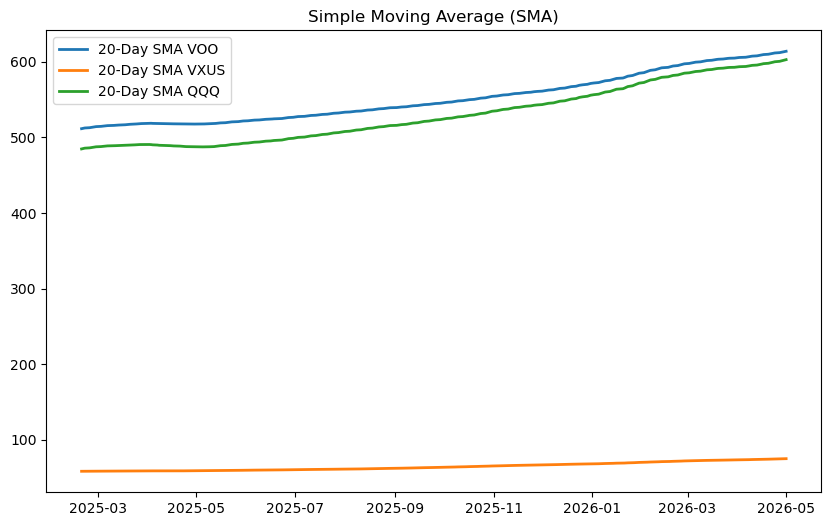

In [63]:
import matplotlib.pyplot as plt # Plotting

df = download_data()

latest = df.iloc[-1]
ma200 = df.rolling(MA_DAYS)

# Window size = 20
df['SMA_200_VOO'] = df['VOO'].rolling(window=MA_DAYS).mean()
df['SMA_200_VXUS'] = df['VXUS'].rolling(window=MA_DAYS).mean()
df['SMA_200_QQQ'] = df['QQQ'].rolling(window=MA_DAYS).mean()

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(df['SMA_200_VOO'], label='20-Day SMA VOO', linewidth=2)
plt.plot(df['SMA_200_VXUS'], label='20-Day SMA VXUS', linewidth=2)
plt.plot(df['SMA_200_QQQ'], label='20-Day SMA QQQ', linewidth=2)

plt.title('Simple Moving Average (SMA)')
plt.legend()
plt.show()
